# Lab 1: Data and Embeddings

This notebook introduces the dataset and illustrates how the raw inputs are structured. Notebooks 2 and 3 are fully self-contained and do not depend on this one.

## Background

The data come from Amazon.com and cover toy products observed between March 2023 and January 2024. For each product, we observe monthly snapshots of the sales rank and the buy-box price, together with product descriptions and images. The dataset contains approximately 7,000 unique products tracked over 12 four-week periods.

## Notation and Variable Definitions

Let $i$ index products and $t$ index time periods. The two central variables are defined as follows.

**Quantity signal.** Amazon does not publish unit sales directly. We use the sales rank as a proxy. Higher sales rank means fewer units sold, so we invert it. The quantity signal is
$$Q_{it} = \log\!\bigl(1/\text{Time-Averaged Sales Rank of } i \text{ in period } t\bigr).$$
A higher value of $Q_{it}$ corresponds to a product selling more units relative to competitors in the category.

**Price signal.** The buy-box price is the price shown to buyers considering immediate purchase. We transform it as
$$P_{it} = \log\!\bigl(\text{Time-Averaged Price of } i \text{ in period } t\bigr).$$
Working in logs means that regression coefficients can be interpreted as approximate elasticities.

**Temporal changes.** We define the first differences
$$\Delta Q_{it} := Q_{it} - Q_{i,t-1}, \qquad \Delta P_{it} := P_{it} - P_{i,t-1}.$$

**Remark (Pareto interpretation).** Under a Pareto distribution with shape parameter $\vartheta$ for units sold, the price sensitivity of actual demand is approximately $1/\vartheta$ times the rank elasticity.With $\hat{\vartheta} \approx 0.5$ for toys on Amazon, multiplying rank elasticity estimates by $1/\hat{\vartheta} \approx 2$ gives approximate demand elasticities.

## Raw Inputs and Embeddings

Each product has a multimodal input vector $X^{in}_i = [\text{Text}_i,\; \text{Image}_i]^T$. The text description and image are passed through transformer-based models (RoBERTa for text, BEiT for images), producing embeddings $E_i = (T_i, I_i)$. These are compressed to 256 dimensions via a Johnson-Lindenstrauss random projection, yielding $\bar{E}_i \in \mathbb{R}^{256}$.

The projected embeddings are centered and normalized to the unit hypersphere:
$$X^e_i := \frac{\bar{E}_i - n^{-1}\sum_j \bar{E}_j}{\bigl\|\bar{E}_i - n^{-1}\sum_j \bar{E}_j\bigr\|}.$$
These vectors serve as rich product-level controls that capture quality, style, and category information not available in structured form.

Because the raw embedding space is high-dimensional, we summarize it in two ways for use in regression:
- **PCA projections**: $X^{pc}_{i,k} := \gamma_k^T X^e_i$ for $k = 1, \ldots, K$, where $\gamma_k$ is the $k$-th eigenvector of the covariance matrix of $X^e_i$.
- **Cluster similarities**: $X^{sim}_{i,k} := c_k^T X^e_i$ for $k = 1, \ldots, K$, where $c_k$ is the centroid of the $k$-th cluster from k-means with $K = 5$. Since $X^e_i$ lies on the unit hypersphere, the inner product represents cosine similarity.

These summaries play a central role in the causal estimation in Lab 3.

In [1]:
import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

palette = sns.color_palette("colorblind")

## Loading the Dataset

The dataset is hosted on HuggingFace. It is split into a training set and a test set. We use this split throughout all three labs.

In [2]:
ds = datasets.load_dataset("janteichertkluge/demand-analysis-repro")
print(ds)

ds_train = ds["train"]
ds_test  = ds["test"]
print(f"\nTrain: {len(ds_train):,} observations")
print(f"Test:  {len(ds_test):,} observations")

Using the latest cached version of the dataset since janteichertkluge/demand-analysis-repro couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Work\.cache\huggingface\datasets\janteichertkluge___demand-analysis-repro\default\0.0.0\6865abe05af2025091f0f3e777d4639224cafddc (last modified on Wed Mar 25 15:40:37 2026).


DatasetDict({
    train: Dataset({
        features: ['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window', 'REVIEW_COUNT', 'RATING', 'New Offer Count: Current', 'Count of retrieved live offers: New, FBA', 'Count of retrieved live offers: New, FBM', 'Lightning Deals: Upcoming Deal', 'Buy Box: Is FBA', 'subcat_aggregated', 'date_t', 'Airplanes', 'Cars & Race Cars', 'Motor Vehicles', 'Race Tracks', 'Residual', 'Skateboards', 'Tractors', 'Train Sets', 'Trains & Trams', 'Trucks', 'Vehicle Playsets', '2023-01-30', '2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29', 'Airplanes.1', 'Cars & Race Cars.1', 'Motor Vehicles.1', 'Race Tracks.1', 'Residual.1', 'Skateboards.1', 'Tractors.1', 'Train Sets.1', 'Trains & Trams.1', 'Trucks.1', 'Vehicle Playsets.1', 'pred_ml_l', 'pred_ml_m', 'embedding_feature_0', 'embedding_feature_1', 'embedding_feature_2', 'emb

In [3]:
all_cols = ds_train.column_names
emb_cols = sorted([c for c in all_cols if c.startswith("emb_")])
meta_cols = [c for c in all_cols if c not in emb_cols]

print(f"Embedding dimensions:  {len(emb_cols)}")
print(f"Structured variables:  {len(meta_cols)}")
print("\nStructured columns:")
for c in meta_cols:
    print(" ", c)

Embedding dimensions:  5
Structured variables:  70

Structured columns:
  ASIN
  date
  index
  Q_t
  PRICE
  P_bb_t
  text
  window
  REVIEW_COUNT
  RATING
  New Offer Count: Current
  Count of retrieved live offers: New, FBA
  Count of retrieved live offers: New, FBM
  Lightning Deals: Upcoming Deal
  Buy Box: Is FBA
  subcat_aggregated
  date_t
  Airplanes
  Cars & Race Cars
  Motor Vehicles
  Race Tracks
  Residual
  Skateboards
  Tractors
  Train Sets
  Trains & Trams
  Trucks
  Vehicle Playsets
  2023-01-30
  2023-02-27
  2023-03-27
  2023-04-24
  2023-05-22
  2023-06-19
  2023-07-17
  2023-08-14
  2023-09-11
  2023-10-09
  2023-11-06
  2023-12-04
  2024-01-01
  2024-01-29
  Airplanes.1
  Cars & Race Cars.1
  Motor Vehicles.1
  Race Tracks.1
  Residual.1
  Skateboards.1
  Tractors.1
  Train Sets.1
  Trains & Trams.1
  Trucks.1
  Vehicle Playsets.1
  pred_ml_l
  pred_ml_m
  embedding_feature_0
  embedding_feature_1
  embedding_feature_2
  embedding_feature_3
  embedding_feature_4


In [4]:
df_train = ds_train.to_pandas()
df_test  = ds_test.to_pandas()

df_train[["ASIN", "date", "Q_t", "P_bb_t"]].head()

,ASIN,date,Q_t,P_bb_t
0,1947335162,2023-02-27,-12.600586,3.555062
1,1947335162,2023-03-27,-12.515369,3.633271
2,1947335162,2023-04-24,-12.576837,3.582963
3,1947335162,2023-05-22,-12.688608,3.587493
4,1947335162,2023-06-19,-12.238366,3.555062


## Descriptive Statistics

We look at the distributions of the quantity and price signals and the number of products per subcategory.

In [5]:
df_train[["Q_t", "P_bb_t", "REVIEW_COUNT", "RATING"]].describe().round(3)

,Q_t,P_bb_t,REVIEW_COUNT,RATING
count,38146.000,38146.000,38146.000,38146.000
mean,-11.120,3.042,871.516,4.494
std,1.301,0.625,2943.238,0.344
min,-14.169,1.356,-1.000,1.000
25%,-12.045,2.638,34.000,4.318
50%,-11.368,2.995,158.714,4.582
75%,-10.416,3.381,655.018,4.700
max,-2.969,7.473,100314.357,5.000


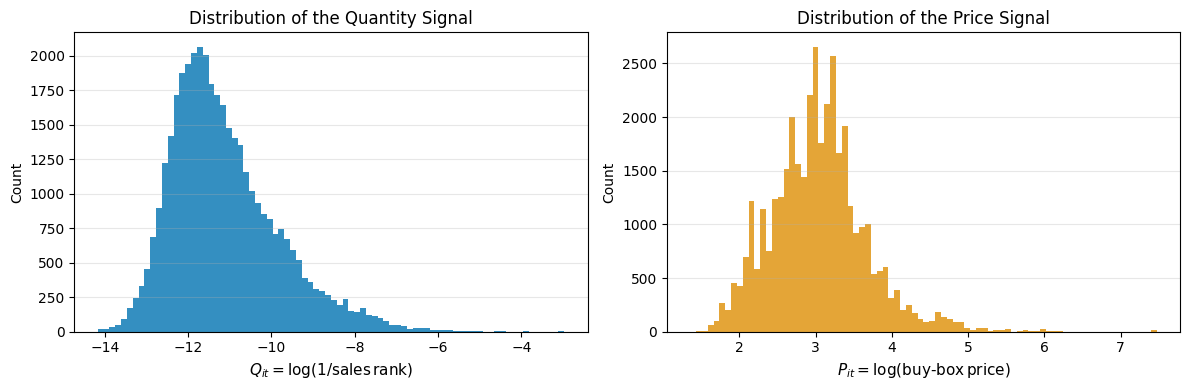

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train["Q_t"].dropna(), bins=80, color=palette[0], alpha=0.8, edgecolor="none")
axes[0].set_xlabel("$Q_{it} = \\log(1/\\mathrm{sales\\, rank})$", fontsize=11)
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of the Quantity Signal")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(df_train["P_bb_t"].dropna(), bins=80, color=palette[1], alpha=0.8, edgecolor="none")
axes[1].set_xlabel("$P_{it} = \\log(\\mathrm{buy\\text{-}box\\, price})$", fontsize=11)
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of the Price Signal")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
if "subcat_aggregated" in df_train.columns:
    print("Products per subcategory (training set):")
    print(df_train.groupby("subcat_aggregated")["ASIN"].nunique().sort_values(ascending=False).to_string())

Products per subcategory (training set):
subcat_aggregated
Cars & Race Cars    1170
Trucks               668
Residual             634
Skateboards          332
Train Sets           308
Vehicle Playsets     131
Airplanes            112
Race Tracks          111
Motor Vehicles       101
Trains & Trams        90
Tractors              60


## Time Series Overview

To get a feel for the data, we plot the median quantity and price signal over time. The panel is unbalanced, so these medians mix products entering and leaving the sample.

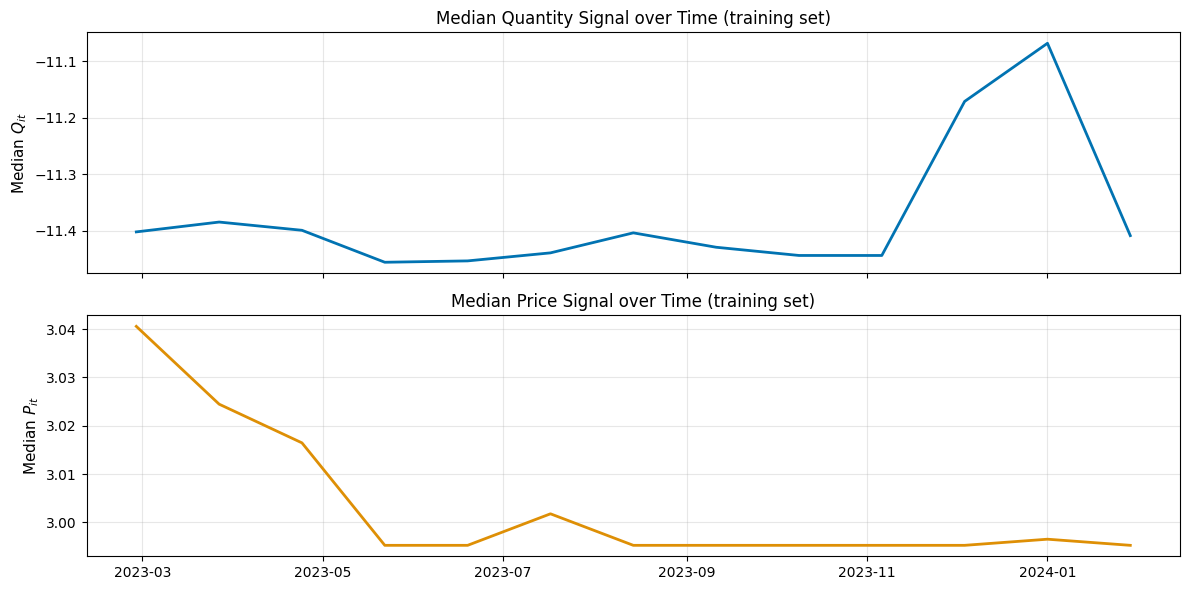

In [8]:
df_train["date_dt"] = pd.to_datetime(df_train["date"])
monthly = df_train.groupby("date_dt")[["Q_t", "P_bb_t"]].median()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(monthly.index, monthly["Q_t"], color=palette[0], linewidth=2)
axes[0].set_ylabel("Median $Q_{it}$", fontsize=11)
axes[0].set_title("Median Quantity Signal over Time (training set)")
axes[0].grid(alpha=0.3)

axes[1].plot(monthly.index, monthly["P_bb_t"], color=palette[1], linewidth=2)
axes[1].set_ylabel("Median $P_{it}$", fontsize=11)
axes[1].set_title("Median Price Signal over Time (training set)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Embedding Structure

The concatenated embeddings $E_i = (T_i, I_i)$ are compressed via Johnson-Lindenstrauss projection to $\bar{E}_i \in \mathbb{R}^{256}$, then centered (subtract training mean) and L2-normalized to the unit hypersphere:
$$X^e_i := \frac{\bar{E}_i - n^{-1}\sum_j \bar{E}_j}{\bigl\|\bar{E}_i - n^{-1}\sum_j \bar{E}_j\bigr\|}.$$

We then apply PCA to visualize the main axes of variation. The PCA projections are $X^{pc}_{i,k} := \gamma_k^T X^e_i$, where $\gamma_k$ is the $k$-th eigenvector of the covariance matrix of $X^e_i$.

Normalizing to unit length ensures that all products are compared by direction rather than magnitude, which is standard practice when working with transformer embeddings.

In [9]:
emb_tr = df_train[emb_cols].values.astype(float)
emb_te = df_test[emb_cols].values.astype(float)

global_mean = emb_tr.mean(axis=0)
emb_tr_n = normalize(emb_tr - global_mean, axis=1)
emb_te_n = normalize(emb_te - global_mean, axis=1)

pca3 = PCA(n_components=3, random_state=42)
pca3.fit(emb_tr_n)

print("Variance explained by PCA components:")
for i, ev in enumerate(pca3.explained_variance_ratio_):
    cumulative = pca3.explained_variance_ratio_[:i+1].sum()
    print(f"  PC{i+1:2d}:  {ev:.3f}  (cumulative: {cumulative:.3f})")

Variance explained by PCA components:
  PC 1:  0.735  (cumulative: 0.735)
  PC 2:  0.257  (cumulative: 0.992)
  PC 3:  0.008  (cumulative: 0.999)


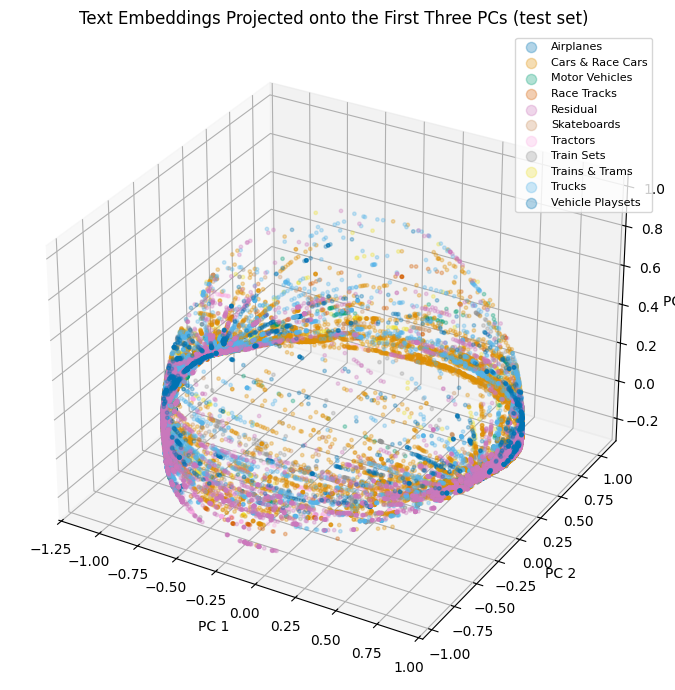

In [10]:
coords = pca3.transform(emb_te_n)

if "subcat_aggregated" in df_test.columns:
    cats = df_test["subcat_aggregated"].astype("category")
    codes = cats.cat.codes.values
else:
    cats  = pd.Categorical(["all"] * len(coords))
    codes = np.zeros(len(coords), dtype=int)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
for i, cat in enumerate(cats.cat.categories):
    mask = codes == i
    ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
               label=cat, alpha=0.3, s=6, color=palette[i % len(palette)])
ax.set_xlabel("PC 1", fontsize=10)
ax.set_ylabel("PC 2", fontsize=10)
ax.set_zlabel("PC 3", fontsize=10)
ax.set_title("Text Embeddings Projected onto the First Three PCs (test set)")
ax.legend(markerscale=3, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

## K-Means Clustering

We fit a k-means model with $K = 5$ clusters to the normalized training embeddings. The resulting centroids $c_1, \ldots, c_K$ define the similarity variables used in the regression models. The $k$-th similarity score for product $i$ is
$$X^{sim}_{i,k} := c_k^T X^e_i, \quad k = 1, \ldots, K.$$
Since $X^e_i$ lies on the unit hypersphere, the inner product $c_k^T X^e_i$ directly represents cosine similarity (up to normalization of $c_k$). The resulting compressed vector $X^{sim}_i = (X^{sim}_{i,k})_{k=1}^K \in \mathbb{R}^K$ enters the control function in Labs 2 and 3.

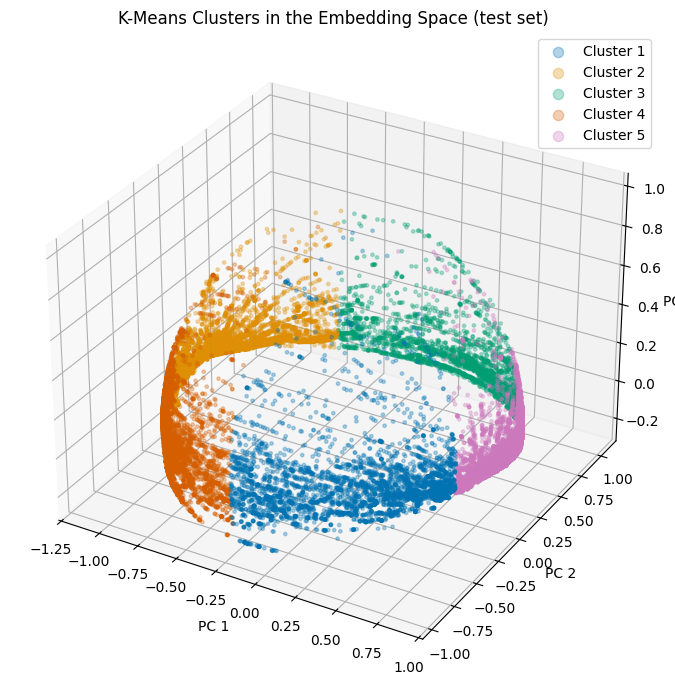

Products per cluster (test set):
  Cluster 1: 4,476
  Cluster 2: 10,717
  Cluster 3: 3,280
  Cluster 4: 6,513
  Cluster 5: 13,055


In [11]:
km = KMeans(n_clusters=5, random_state=42, n_init=50)
labels = km.fit_predict(emb_te_n)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
for k in range(5):
    mask = labels == k
    ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
               label=f"Cluster {k+1}", alpha=0.3, s=6, color=palette[k])
ax.set_xlabel("PC 1", fontsize=10)
ax.set_ylabel("PC 2", fontsize=10)
ax.set_zlabel("PC 3", fontsize=10)
ax.set_title("K-Means Clusters in the Embedding Space (test set)")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

print("Products per cluster (test set):")
for k in range(5):
    print(f"  Cluster {k+1}: {(labels == k).sum():,}")

## Naive Effect Estimation

In [12]:
import statsmodels.api as sm

# Regress Q_t on P_bb_t

model = sm.OLS(df_test['Q_t'], sm.add_constant(df_test['P_bb_t']))
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                    Q_t   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     103.5
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           2.83e-24
Time:                        13:01:28   Log-Likelihood:                -64416.
No. Observations:               38041   AIC:                         1.288e+05
Df Residuals:                   38039   BIC:                         1.289e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -10.7561      0.034   -319.789      0.0

In [13]:
# Regress Q_t on P_bb_t with tabular controls

tabular_controls = [
    "RATING", "REVIEW_COUNT",]
X = sm.add_constant(df_test['P_bb_t'])
for c in tabular_controls:
    X[c] = df_test[c]

# add subcategory dummies if available
if "subcat_aggregated" in df_test.columns:
    sub_te = pd.get_dummies(df_test["subcat_aggregated"], prefix="sub", drop_first=True).astype(int)
    X = pd.concat([X, sub_te], axis=1)

model = sm.OLS(df_test['Q_t'], X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    Q_t   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     680.8
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:01:28   Log-Likelihood:                -60488.
No. Observations:               38041   AIC:                         1.210e+05
Df Residuals:                   38027   BIC:                         1.211e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -11.2488 